In [1]:
import matplotlib
import matplotlib.pyplot as plt

# Chinese font fix — run once per notebook
matplotlib.rcParams['font.sans-serif'] = [
    'PingFang HK', 'Microsoft YaHei', 'SimHei',
    'WenQuanYi Micro Hei', 'Arial Unicode MS'
]
matplotlib.rcParams['axes.unicode_minus'] = False

In [2]:
from utils import get_stock_data, get_stock_data_cached, plot_stock
stocks = {
    'sz.000001': '平安银行',
    'sz.300229': '拓尔思',
    'sh.688658': '悦康药业',
    'sh.600597': '光明乳业',
    'sh.601187': '厦门银行',
    'sh.601595': '上海电影',
    'sh.601022': '宁波远洋',
    'sz.300352': '北信源',
    'sh.600116': '三峡水利',
    'sz.000901': '航天科技',
    'sz.002139': '拓邦股份'
}

start = '2024-04-01'
end = '2025-04-01'

from utils import detect_gaps

for code, name in stocks.items():
    df = get_stock_data_cached(code, start, end)
    if not df.empty:
        gaps = detect_gaps(df)
        if not gaps.empty:
            print(f"\n{name} {code} — found {len(gaps)} gap(s):")
            print(gaps)
        else:
            print(f"{name} {code} — no gaps detected")

Loading from cache: data\sz.000001_2024-04-01_2025-04-01_d_2.csv

平安银行 sz.000001 — found 3 gap(s):
  resume_date last_trade_date  calendar_days
0  2024-05-06      2024-04-30            6.0
1  2024-10-08      2024-09-30            8.0
2  2025-02-05      2025-01-27            9.0
Loading from cache: data\sz.300229_2024-04-01_2025-04-01_d_2.csv

拓尔思 sz.300229 — found 3 gap(s):
  resume_date last_trade_date  calendar_days
0  2024-05-06      2024-04-30            6.0
1  2024-10-08      2024-09-30            8.0
2  2025-02-05      2025-01-27            9.0
Loading from cache: data\sh.688658_2024-04-01_2025-04-01_d_2.csv

悦康药业 sh.688658 — found 3 gap(s):
  resume_date last_trade_date  calendar_days
0  2024-05-06      2024-04-30            6.0
1  2024-10-08      2024-09-30            8.0
2  2025-02-05      2025-01-27            9.0
Loading from cache: data\sh.600597_2024-04-01_2025-04-01_d_2.csv

光明乳业 sh.600597 — found 3 gap(s):
  resume_date last_trade_date  calendar_days
0  2024-05-06      2

Loading from cache: data\sz.000001_2024-04-01_2025-04-01_d_2.csv
Loading from cache: data\sz.300229_2024-04-01_2025-04-01_d_2.csv
Loading from cache: data\sh.688658_2024-04-01_2025-04-01_d_2.csv
Loading from cache: data\sh.600597_2024-04-01_2025-04-01_d_2.csv
Loading from cache: data\sh.601187_2024-04-01_2025-04-01_d_2.csv
Loading from cache: data\sh.601595_2024-04-01_2025-04-01_d_2.csv
Loading from cache: data\sh.601022_2024-04-01_2025-04-01_d_2.csv
Loading from cache: data\sz.300352_2024-04-01_2025-04-01_d_2.csv
Loading from cache: data\sh.600116_2024-04-01_2025-04-01_d_2.csv
Loading from cache: data\sz.000901_2024-04-01_2025-04-01_d_2.csv
Loading from cache: data\sz.002139_2024-04-01_2025-04-01_d_2.csv


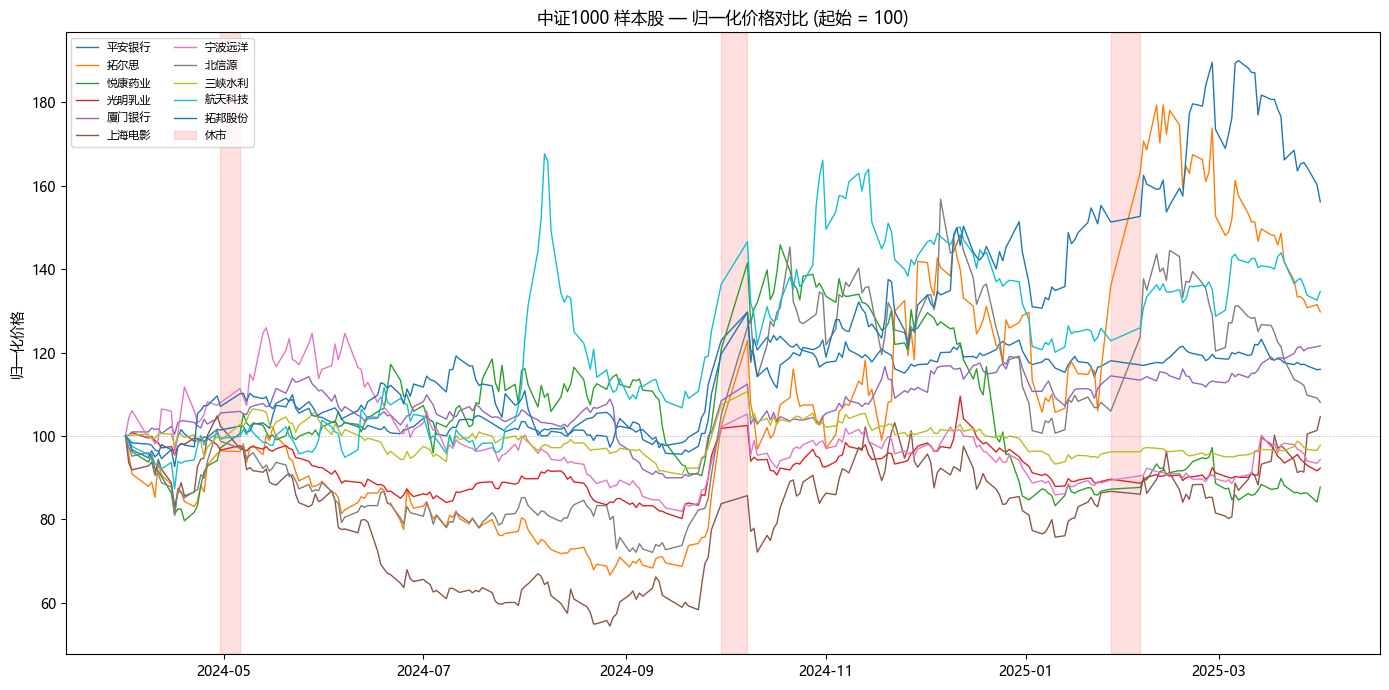

In [3]:
fig, ax = plt.subplots(figsize=(14, 7))

for code, name in stocks.items():
    df = get_stock_data_cached(code, start, end)
    if not df.empty:
        normalized = df['close'] / df['close'].iloc[0] * 100
        ax.plot(normalized.index, normalized, linewidth=1, label=name)

# Shade gaps — only need one stock's gaps since they're all holidays
gaps = detect_gaps(df)  # df is the last stock loaded, but gaps are the same
for i, row in gaps.iterrows():
    ax.axvspan(row['last_trade_date'], row['resume_date'],
               alpha=0.12, color='red', 
               label='休市' if i == 0 else None)

ax.axhline(100, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
ax.set_title('中证1000 样本股 — 归一化价格对比 (起始 = 100)')
ax.set_ylabel('归一化价格')
ax.legend(fontsize=8, loc='upper left', ncol=2)
fig.tight_layout()
fig.savefig('charts/all_stocks_normalized_with_gaps.png', dpi=150, 
            bbox_inches='tight')
plt.show()

Loading from cache: data\sz.000001_2024-04-01_2025-04-01_d_2.csv
login success!
logout success!


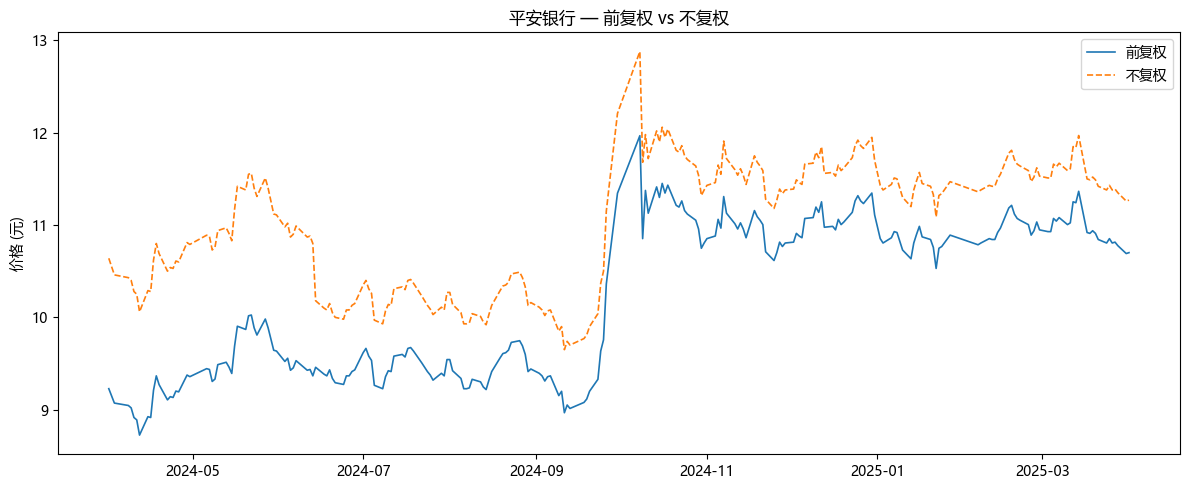

In [4]:
# Pull the same stock with different adjustment flags
df_qfq = get_stock_data_cached('sz.000001', '2024-04-01', '2025-04-01', 
                                adjust='2')  # 前复权
df_raw = get_stock_data('sz.000001', '2024-04-01', '2025-04-01', 
                         adjust='3')  # 不复权 (don't cache this one)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_qfq.index, df_qfq['close'], label='前复权', linewidth=1.2)
ax.plot(df_raw.index, df_raw['close'], label='不复权', linewidth=1.2, 
        linestyle='--')
ax.set_title('平安银行 — 前复权 vs 不复权')
ax.legend()
ax.set_ylabel('价格 (元)')
fig.tight_layout()
plt.show()

In [6]:
import traceback

test_cases = [
    ('000001', '2024-01-01', '2024-12-31', 'Wrong format'),
    ('sz.999999', '2024-01-01', '2024-12-31', 'Fake code'),
    ('sz.300229', '2000-01-01', '2005-12-31', 'Before listing'),
    ('sz.000001', '2025-01-01', '2024-01-01', 'Flipped dates'),
]

for code, start, end, label in test_cases:
    print(f"\n--- Test: {label} ---")
    try:
        df = get_stock_data(code, start, end)
        print(f"Result: DataFrame with {len(df)} rows")
    except Exception as e:
        print(f"Error: {type(e).__name__}: {e}")


--- Test: Wrong format ---
Error: ValueError: Stock code '000001' missing exchange prefix. Use 'sz.000001' or 'sh.600000' format.

--- Test: Fake code ---
login success!
logout success!
Result: DataFrame with 0 rows

--- Test: Before listing ---
login success!
logout success!
Result: DataFrame with 0 rows

--- Test: Flipped dates ---
login success!
起始日期大于终止日期，请修改。
logout success!
Result: DataFrame with 0 rows
